In [5813]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import matplotlib
import lightgbm as lgb
from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

import re

font_path = 'C:/Windows/Fonts/gulim.ttc'
font = fm.FontProperties(fname=font_path).get_name()
matplotlib.rc("font",family=font)

In [5814]:
df_team = pd.read_csv("../../../EDA/Merge/data/result data/Final DF.csv")  # Year, Nation, ..., DEF_INDEX 등

# 예시: 경기 단위 데이터
df_match = pd.read_csv("./../data/matches_1930_2022.csv")  

In [5815]:
df_team.columns
df_team=df_team[['Year', 'Nation','Eng_Nation','Q_WR', 'Q_GR',
       'F_Rank', 'F_Point', 'F_Rd', 'F_Pd', 'Avg_Apps', 'Avg_Age','Avg_Famous', 'FS_0', 'FS_1', 'FS_2', 'FS_3', 'FS_4', 'FS_5', 'FS_6',
       'FS_7', 'FS_8', 'FS_9', 'FS_10', 'FS_11', 'FS_12', 'FS_13']]

In [5816]:
df_match = df_match[['Year','home_team','away_team','home_score','away_score','Score']]
df_fin = df_match

In [5817]:
country_map = {
    "브라질": "Brazil",
    "독일": "Germany",
    "터키": "Türkiye",
    "대한민국": "Korea Republic",
    "스페인": "Spain",
    "잉글랜드": "England",
    "세네갈": "Senegal",
    "미국": "United States",
    "일본": "Japan",
    "덴마크": "Denmark",
    "멕시코": "Mexico",
    "아일랜드": "Republic of Ireland",
    "스웨덴": "Sweden",
    "벨기에": "Belgium",
    "이탈리아": "Italy",
    "파라과이": "Paraguay",
    "남아프리카 공화국": "South Africa",
    "아르헨티나": "Argentina",
    "코스타리카": "Costa Rica",
    "카메룬": "Cameroon",
    "포르투갈": "Portugal",
    "러시아": "Russia",
    "크로아티아": "Croatia",
    "에콰도르": "Ecuador",
    "폴란드": "Poland",
    "우루과이": "Uruguay",
    "나이지리아": "Nigeria",
    "프랑스": "France",
    "튀니지": "Tunisia",
    "슬로베니아": "Slovenia",
    "중국": "China PR",
    "사우디아라비아": "Saudi Arabia",
    "우크라이나": "Ukraine",
    "스위스": "Switzerland",
    "네덜란드": "Netherlands",
    "가나": "Ghana",
    "호주": "Australia",
    "코트디부아르": "Côte d'Ivoire",
    "체코": "Czech Republic",
    "앙골라": "Angola",
    "이란": "IR Iran",
    "트리니다드 토바고": "Trinidad and Tobago",
    "토고": "Togo",
    "세르비아 몬테네그로": "Serbia and Montenegro",
    "칠레": "Chile",
    "슬로바키아": "Slovakia",
    "뉴질랜드": "New Zealand",
    "세르비아": "Serbia",
    "그리스": "Greece",
    "알제리": "Algeria",
    "온두라스": "Honduras",
    "북한": "Korea DPR",
    "콜롬비아": "Colombia",
    "보스니아 헤르체고비나": "Bosnia and Herzegovina",
    "페루": "Peru",
    "모로코": "Morocco",
    "아이슬란드": "Iceland",
    "이집트": "Egypt",
    "파나마": "Panama",
    "웨일스": "Wales",
    "캐나다": "Canada",
    "카타르": "Qatar",
}

In [5818]:


# ---------------------------
# 0️⃣ 2002년 이후 경기만 선택
# ---------------------------
df_match_filtered = df_match[df_match['Year'] >= 2002].reset_index(drop=True)

# ---------------------------
# 1️⃣ 팀 데이터에 영어 이름 컬럼 추가 (country_map 사용)
# ---------------------------
df_team['Eng_Nation'] = df_team['Nation'].map(country_map)

# ---------------------------
# 2️⃣ Year + Eng_Nation 기준 인덱스 설정
# ---------------------------
df_team_renamed = df_team.set_index(['Year', 'Eng_Nation'])

# ---------------------------
# 3️⃣ 매핑 실패 팀 기록용
# ---------------------------
missing_teams = set()

# ---------------------------
# 4️⃣ 점수 문자열에서 최종 결과 계산
# ---------------------------
def parse_result_from_score(score_str):
    """
    score_str 예시: "3–3", "(4) 3–3 (2)", "2–1"
    반환: 1 = 홈승, 0 = 무승부, -1 = 홈패
    """
    # 정규/연장 점수 추출
    main_match = re.search(r'(\d+)\s*–\s*(\d+)', score_str)
    if not main_match:
        return None  # 점수 형식 이상
    
    home_main = int(main_match.group(1))
    away_main = int(main_match.group(2))
    
    # 점수가 다르면 정규/연장으로 승패 결정
    if home_main > away_main:
        return 1
    elif home_main < away_main:
        return -1
    else:
        # 동점이면 승부차기 점수 확인
        pens = re.findall(r'\((\d+)\)', score_str)
        if len(pens) == 2:
            home_pen = int(pens[0])
            away_pen = int(pens[1])
            if home_pen > away_pen:
                return 1
            elif home_pen < away_pen:
                return -1
        # 승부차기 없거나 동점이면 무승부
        return 0

# ---------------------------
# 5️⃣ 홈/어웨이 팀 특징 매핑 함수
# ---------------------------
def map_team_features_safe(row):
    year = row['Year']
    home = row['home_team']
    away = row['away_team']
    
    # 홈팀 특징
    try:
        home_feat = df_team_renamed.loc[(year, home)].add_prefix("Home_")
    except KeyError:
        missing_teams.add(home)
        home_feat = pd.Series(dtype=float)
    
    # 어웨이팀 특징
    try:
        away_feat = df_team_renamed.loc[(year, away)].add_prefix("Away_")
    except KeyError:
        missing_teams.add(away)
        away_feat = pd.Series(dtype=float)
    
    # 경기 결과 계산 (홈승=1, 무승부=0, 홈패=-1)
    result = parse_result_from_score(row['Score'])

    return pd.concat([pd.Series({'Year': year}), home_feat, away_feat, pd.Series({'Result': result})])

# ---------------------------
# 6️⃣ 적용
# ---------------------------
df_final = df_match_filtered.apply(map_team_features_safe, axis=1).reset_index(drop=True)

# ---------------------------
# 7️⃣ 매핑 실패 팀 확인
# ---------------------------
if missing_teams:
    print("매핑이 안 된 팀:", missing_teams)

# ---------------------------
# 8️⃣ 결과 확인
# ---------------------------
print(df_final.head())


   Year Home_Nation  Home_Q_WR  Home_Q_GR  Home_F_Rank  Home_F_Point  \
0  2022       아르헨티나       0.52   3.888889         8.33       1654.10   
1  2022       크로아티아       0.54   1.479452        11.00       1620.42   
2  2022         프랑스       0.63   2.830189         2.67       1741.10   
3  2022       아르헨티나       0.52   3.888889         8.33       1654.10   
4  2022         모로코       0.51   3.055556        38.33       1470.74   

   Home_F_Rd  Home_F_Pd  Home_Avg_Apps  Home_Avg_Age  ...  Away_FS_5  \
0       6.58     190.35        0.50000         27.81  ...      56.58   
1      -4.00     592.92        0.46154         27.42  ...      54.26   
2     -10.66     644.77        0.65385         26.69  ...      54.26   
3       6.58     190.35        0.50000         27.81  ...      59.85   
4     -28.00     938.74        0.23077         26.31  ...      59.48   

   Away_FS_6  Away_FS_7  Away_FS_8  Away_FS_9  Away_FS_10  Away_FS_11  \
0      71.88      68.46      74.35      68.04       73.38    

In [5819]:
df = df_final
df.columns

Index(['Year', 'Home_Nation', 'Home_Q_WR', 'Home_Q_GR', 'Home_F_Rank',
       'Home_F_Point', 'Home_F_Rd', 'Home_F_Pd', 'Home_Avg_Apps',
       'Home_Avg_Age', 'Home_Avg_Famous', 'Home_FS_0', 'Home_FS_1',
       'Home_FS_2', 'Home_FS_3', 'Home_FS_4', 'Home_FS_5', 'Home_FS_6',
       'Home_FS_7', 'Home_FS_8', 'Home_FS_9', 'Home_FS_10', 'Home_FS_11',
       'Home_FS_12', 'Home_FS_13', 'Away_Nation', 'Away_Q_WR', 'Away_Q_GR',
       'Away_F_Rank', 'Away_F_Point', 'Away_F_Rd', 'Away_F_Pd',
       'Away_Avg_Apps', 'Away_Avg_Age', 'Away_Avg_Famous', 'Away_FS_0',
       'Away_FS_1', 'Away_FS_2', 'Away_FS_3', 'Away_FS_4', 'Away_FS_5',
       'Away_FS_6', 'Away_FS_7', 'Away_FS_8', 'Away_FS_9', 'Away_FS_10',
       'Away_FS_11', 'Away_FS_12', 'Away_FS_13', 'Result'],
      dtype='object')

In [5820]:
# 홈/어웨이 컬럼 분리
home_cols = [col for col in df.columns if col.startswith('Home_')]
away_cols = [col for col in df.columns if col.startswith('Away_')]

# 컬럼 이름 접두사 바꾸기
home_rename = {col: col.replace('Home_', 'Away_') for col in home_cols}
away_rename = {col: col.replace('Away_', 'Home_') for col in away_cols}

# 데이터 복사 후 컬럼 교체
df_swapped = df.copy()
df_swapped = df_swapped.rename(columns={**home_rename, **away_rename})

# Result 반대로 바꾸기
df_swapped['Result'] = df_swapped['Result'].replace({1: -1, -1: 1, 0: 0})

# 원본과 합치기
df_expanded = pd.concat([df, df_swapped], ignore_index=True)

print(df_expanded.shape)
print(df_expanded.head())


(768, 50)
   Year Home_Nation  Home_Q_WR  Home_Q_GR  Home_F_Rank  Home_F_Point  \
0  2022       아르헨티나       0.52   3.888889         8.33       1654.10   
1  2022       크로아티아       0.54   1.479452        11.00       1620.42   
2  2022         프랑스       0.63   2.830189         2.67       1741.10   
3  2022       아르헨티나       0.52   3.888889         8.33       1654.10   
4  2022         모로코       0.51   3.055556        38.33       1470.74   

   Home_F_Rd  Home_F_Pd  Home_Avg_Apps  Home_Avg_Age  ...  Away_FS_5  \
0       6.58     190.35        0.50000         27.81  ...      56.58   
1      -4.00     592.92        0.46154         27.42  ...      54.26   
2     -10.66     644.77        0.65385         26.69  ...      54.26   
3       6.58     190.35        0.50000         27.81  ...      59.85   
4     -28.00     938.74        0.23077         26.31  ...      59.48   

   Away_FS_6  Away_FS_7  Away_FS_8  Away_FS_9  Away_FS_10  Away_FS_11  \
0      71.88      68.46      74.35      68.04      

In [5821]:
home_cols = [col for col in df_final.columns if col.startswith('Home_')]
away_cols = [col for col in df_final.columns if col.startswith('Away_')]

# Nation 같은 문자열 컬럼 제외
home_cols = [c for c in home_cols if c not in ["Home_Nation"]]
away_cols = [c for c in away_cols if c not in ["Away_Nation"]]

# 공통 지표 이름 추출 (Home_ 접두사 제거)
metrics = [col.replace("Home_", "") for col in home_cols]

diff_data = {}

for metric in metrics:
    home_col = f"Home_{metric}"
    away_col = f"Away_{metric}"
    
    # 두 컬럼이 존재하고 수치형일 때만 처리
    if home_col in df_final.columns and away_col in df_final.columns:
        if pd.api.types.is_numeric_dtype(df_final[home_col]) and pd.api.types.is_numeric_dtype(df_final[away_col]):
            diff_data[metric] = df_final[home_col] - df_final[away_col]

# 결과 컬럼 추가
diff_data["Result"] = df_final["Result"]
diff_data["Year"] = df_final["Year"]


# Home, Away 팀 한글 → 영어 매핑
diff_data["Home_Eng_Nation"] = df_final["Home_Nation"].map(country_map)
diff_data["Away_Eng_Nation"] = df_final["Away_Nation"].map(country_map)

# 최종 데이터프레임 생성
df_diff = pd.DataFrame(diff_data)

print(df_diff.head())


   Q_WR      Q_GR  F_Rank  F_Point   F_Rd    F_Pd  Avg_Apps  Avg_Age  \
0 -0.11  1.058700    5.66   -87.00  17.24 -454.42  -0.15385     1.12   
1  0.03 -1.576104  -27.33   149.68  24.00 -345.82   0.23077     1.11   
2  0.12 -0.225367  -35.66   270.36  17.34 -293.97   0.42308     0.38   
3 -0.02  2.409437   -2.67    33.68  10.58 -402.57   0.03846     0.39   
4 -0.16 -0.476359   32.66  -186.23 -28.17  528.27  -0.38461    -0.57   

   Avg_Famous  FS_0  ...   FS_8  FS_9  FS_10  FS_11  FS_12  FS_13  Result  \
0           2 -1.34  ...  -5.54  1.69  -1.96  -0.25  -1.94  -0.90       1   
1           1  0.76  ...   5.29  1.41   0.62  -5.60   3.38   7.11       1   
2           5  7.76  ...  10.26  2.95   5.73  -2.80   9.47  11.02       1   
3           6  5.66  ...  -0.57  3.23   3.15   2.55   4.15   3.01       1   
4          -9 -5.61  ...  -3.71 -6.35  -1.07   2.82  -5.97  -6.29       1   

   Year  Home_Eng_Nation  Away_Eng_Nation  
0  2022        Argentina           France  
1  2022         

In [5822]:
df_diff = df_diff[df_diff['Result'] != 0]
df_diff['Result'].unique()

array([ 1, -1])

In [5823]:
df_diff.to_csv('./../data/before_record.csv')

---
results 데이터

In [5824]:
df_record = pd.read_csv('./../data/results.csv')
df_record.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48532 entries, 0 to 48531
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        48532 non-null  object
 1   home_team   48532 non-null  object
 2   away_team   48532 non-null  object
 3   home_score  48532 non-null  int64 
 4   away_score  48532 non-null  int64 
 5   tournament  48532 non-null  object
 6   city        48532 non-null  object
 7   country     48532 non-null  object
 8   neutral     48532 non-null  bool  
dtypes: bool(1), int64(2), object(6)
memory usage: 3.0+ MB


In [5825]:
# 년도 범위
df_record = df_record[(df_record['date'] > '1980-01-01') & (df_record['date'] < '2022-01-01')]

In [5826]:
df_record.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32706 entries, 12089 to 44794
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        32706 non-null  object
 1   home_team   32706 non-null  object
 2   away_team   32706 non-null  object
 3   home_score  32706 non-null  int64 
 4   away_score  32706 non-null  int64 
 5   tournament  32706 non-null  object
 6   city        32706 non-null  object
 7   country     32706 non-null  object
 8   neutral     32706 non-null  bool  
dtypes: bool(1), int64(2), object(6)
memory usage: 2.3+ MB


In [5827]:
# # 세부 리그 대략적인 큰 범위로 축소
# def categorize_tournament(t):
#     if t == "FIFA World Cup":
#         return "World Cup "
#     elif t == "FIFA World Cup qualification":
#         return "World Cup Qualifiers"
#     elif "Euro" in t or "UEFA Nations League" in t:
#         return "Europe"
#     elif "AFC" in t or "Asian" in t or "EAFF" in t or "SAFF" in t or "AFF" in t or "CAFA" in t or "ASEAN" in t:
#         return "Asia"
#     elif "Africa" in t or "COSAFA" in t or "CECAFA" in t or "UNIFFAC" in t or "UDEAC" in t:
#         return "Africa"
#     elif "Copa" in t or "Gold Cup" in t or "CONCACAF" in t or "CONMEBOL" in t:
#         return "Americas"
#     elif "Oceania" in t or "Pacific" in t:
#         return "Oceania"
#     elif "Friendly" in t:
#         return "Friendly"
#     else:
#         return "Other/Regional"

# df_record["tournament_category"] = df_record["tournament"].apply(categorize_tournament)

In [5828]:
# df_record['tournament_category'].unique()
# df_record.loc[df_record['tournament_category'] == 'World Cup ', 'tournament_category'] = 'World Cup Qualifiers'
# df_record['tournament_category'].unique()

In [5829]:
# index_to_drop = df_record[df_record['tournament_category'].isin(['Other/Regional', 'World Cup Qualifiers'])].index
# df_record = df_record.drop(index=index_to_drop)

In [5830]:
# df_record['tournament_category'].unique()


In [5831]:
df_record = df_record.drop(['city', 'country', 'tournament', 'neutral'], axis=1)

In [5832]:
df_record

,date,home_team,away_team,home_score,away_score
12089,1980-01-06,Sierra Leone,Ghana,2,4
12090,1980-01-16,Cyprus,Greece,1,1
12091,1980-01-19,Congo,Ivory Coast,2,0
12092,1980-01-20,Congo,Ivory Coast,0,2
12093,1980-01-23,Spain,Netherlands,1,0
...,...,...,...,...,...
44790,2021-12-26,Thailand,Vietnam,0,0
44791,2021-12-29,Indonesia,Thailand,0,4
44792,2021-12-30,Mauritania,Burkina Faso,0,0
44793,2021-12-30,Sudan,Ethiopia,2,3


In [5833]:
df_record["home_win"] = np.sign(df_record["home_score"] - df_record["away_score"])

df_record

,date,home_team,away_team,home_score,away_score,home_win
12089,1980-01-06,Sierra Leone,Ghana,2,4,-1
12090,1980-01-16,Cyprus,Greece,1,1,0
12091,1980-01-19,Congo,Ivory Coast,2,0,1
12092,1980-01-20,Congo,Ivory Coast,0,2,-1
12093,1980-01-23,Spain,Netherlands,1,0,1
...,...,...,...,...,...,...
44790,2021-12-26,Thailand,Vietnam,0,0,0
44791,2021-12-29,Indonesia,Thailand,0,4,-1
44792,2021-12-30,Mauritania,Burkina Faso,0,0,0
44793,2021-12-30,Sudan,Ethiopia,2,3,-1


In [5834]:
df_count = df_record.drop(['home_score', 'away_score'], axis=1)

In [5835]:
df_count = df_count.drop(df_count[df_count['home_win'] == 0].index, axis=0)
df_count

,date,home_team,away_team,home_win
12089,1980-01-06,Sierra Leone,Ghana,-1
12091,1980-01-19,Congo,Ivory Coast,1
12092,1980-01-20,Congo,Ivory Coast,-1
12093,1980-01-23,Spain,Netherlands,1
12094,1980-01-26,Nigeria,Liberia,1
...,...,...,...,...
44788,2021-12-23,Vietnam,Thailand,-1
44789,2021-12-25,Singapore,Indonesia,-1
44791,2021-12-29,Indonesia,Thailand,-1
44793,2021-12-30,Sudan,Ethiopia,-1


In [5836]:
# 날짜 → 연도
df_count["year"] = df_count["date"].str[:4].astype(int)

df_count = df_count.drop('date', axis=1)

In [5837]:
df_count

,home_team,away_team,home_win,year
12089,Sierra Leone,Ghana,-1,1980
12091,Congo,Ivory Coast,1,1980
12092,Congo,Ivory Coast,-1,1980
12093,Spain,Netherlands,1,1980
12094,Nigeria,Liberia,1,1980
...,...,...,...,...
44788,Vietnam,Thailand,-1,2021
44789,Singapore,Indonesia,-1,2021
44791,Indonesia,Thailand,-1,2021
44793,Sudan,Ethiopia,-1,2021


In [5838]:
df_copy = df_count.copy()
df_copy

,home_team,away_team,home_win,year
12089,Sierra Leone,Ghana,-1,1980
12091,Congo,Ivory Coast,1,1980
12092,Congo,Ivory Coast,-1,1980
12093,Spain,Netherlands,1,1980
12094,Nigeria,Liberia,1,1980
...,...,...,...,...
44788,Vietnam,Thailand,-1,2021
44789,Singapore,Indonesia,-1,2021
44791,Indonesia,Thailand,-1,2021
44793,Sudan,Ethiopia,-1,2021


In [5839]:
df_copy['home_team'] = df_count['away_team']
df_copy['away_team'] = df_count['home_team']
df_copy['home_win'] = df_copy['home_win'].apply(lambda x: -1 if x == 1 else 1)

In [5840]:
df_copy

,home_team,away_team,home_win,year
12089,Ghana,Sierra Leone,1,1980
12091,Ivory Coast,Congo,-1,1980
12092,Ivory Coast,Congo,1,1980
12093,Netherlands,Spain,-1,1980
12094,Liberia,Nigeria,-1,1980
...,...,...,...,...
44788,Thailand,Vietnam,1,2021
44789,Indonesia,Singapore,1,2021
44791,Thailand,Indonesia,1,2021
44793,Ethiopia,Sudan,1,2021


In [5841]:
df_count = pd.concat([df_count, df_copy], axis=0).reset_index(drop=True)

---
matches 데이터

In [5842]:
df_fin["home_win"] = (df_fin["home_score"] > df_fin["away_score"]).map({True: 1, False: -1})
df_fin[df_fin['home_win']==0]

,Year,home_team,away_team,home_score,away_score,Score,home_win


In [5843]:
df_fin = df_fin.drop(['home_score', 'away_score', 'Score',], axis=1)

In [5844]:
df_fin

,Year,home_team,away_team,home_win
0,2022,Argentina,France,-1
1,2022,Croatia,Morocco,1
2,2022,France,Morocco,1
3,2022,Argentina,Croatia,1
4,2022,Morocco,Portugal,1
...,...,...,...,...
959,1930,Argentina,France,1
960,1930,Yugoslavia,Brazil,1
961,1930,Romania,Peru,1
962,1930,United States,Belgium,1


In [5845]:
# 년도 범위
df_fin = df_fin[(df_fin['Year'] >= 1980) & (df_fin['Year'] <2022)]

In [5846]:
df_copy2 = df_fin.copy()
df_copy2

,Year,home_team,away_team,home_win
64,2018,France,Croatia,1
65,2018,Belgium,England,1
66,2018,Croatia,England,1
67,2018,France,Belgium,1
68,2018,Sweden,England,-1
...,...,...,...,...
651,1982,Hungary,El Salvador,1
652,1982,Scotland,New Zealand,1
653,1982,Italy,Poland,-1
654,1982,Brazil,Soviet Union,1


In [5847]:
df_copy2['home_team'] = df_fin['away_team']
df_copy2['away_team'] = df_fin['home_team']
df_copy2['home_win'] = df_fin['home_win'].apply(lambda x: -1 if x == 1 else 1)

In [5848]:
df_copy2

,Year,home_team,away_team,home_win
64,2018,Croatia,France,-1
65,2018,England,Belgium,-1
66,2018,England,Croatia,-1
67,2018,Belgium,France,-1
68,2018,England,Sweden,1
...,...,...,...,...
651,1982,El Salvador,Hungary,-1
652,1982,New Zealand,Scotland,-1
653,1982,Poland,Italy,1
654,1982,Soviet Union,Brazil,-1


In [5849]:
df_fin = pd.concat([df_fin, df_copy2], axis=0).reset_index(drop=True)

---
count + fin

In [5850]:
df_fin['home_team'].unique(), df_count['home_team'].unique()

(array(['France', 'Belgium', 'Croatia', 'Sweden', 'Russia', 'Uruguay',
        'Brazil', 'Colombia', 'Spain', 'Japan', 'Senegal', 'England',
        'Panama', 'Korea Republic', 'Mexico', 'Switzerland', 'Serbia',
        'Australia', 'Denmark', 'Iceland', 'Nigeria', 'Saudi Arabia',
        'IR Iran', 'Poland', 'Germany', 'Argentina', 'Portugal', 'Tunisia',
        'Costa Rica', 'Peru', 'Egypt', 'Morocco', 'Netherlands',
        'United States', 'Algeria', 'Bosnia and Herzegovina', 'Honduras',
        'Ecuador', 'Italy', 'Greece', 'Cameroon', 'Ghana', "Côte d'Ivoire",
        'Chile', 'Paraguay', 'Korea DPR', 'Slovakia', 'Slovenia',
        'South Africa', 'New Zealand', 'Ukraine', 'Togo', 'Czech Republic',
        'Serbia and Montenegro', 'Angola', 'Trinidad and Tobago',
        'Türkiye', 'China PR', 'Republic of Ireland', 'Romania',
        'Scotland', 'FR Yugoslavia', 'Jamaica', 'Bulgaria', 'Bolivia',
        'Norway', 'West Germany', 'Yugoslavia', 'Czechoslovakia',
        'Austria'

In [5851]:
country_map = {
    'Korea Republic': 'South Korea',
    'Korea DPR': 'North Korea',
    'IR Iran': 'Iran',
    "Côte d'Ivoire": 'Ivory Coast',
    'Türkiye': 'Turkey',
    'United States': 'United States',
    'Serbia and Montenegro': 'Serbia',
    'China PR': 'China',
    'German DR': 'Germany',
    'United States Virgin Islands': 'United States',
    'DR Congo': 'Congo',
    'Soviet Union': 'Russia',
    'Czechoslovakia': 'Czech Republic',
}

# before_record 기준 컬럼 변환
df_fin['home_team'] = df_fin['home_team'].map(lambda x: country_map.get(x, x))
df_fin['away_team'] = df_fin['away_team'].map(lambda x: country_map.get(x, x))

df_fin = df_fin.rename(columns={'Year': 'year'})
df_fin

,year,home_team,away_team,home_win
0,2018,France,Croatia,1
1,2018,Belgium,England,1
2,2018,Croatia,England,1
3,2018,France,Belgium,1
4,2018,Sweden,England,-1
...,...,...,...,...
1179,1982,El Salvador,Hungary,-1
1180,1982,New Zealand,Scotland,-1
1181,1982,Poland,Italy,1
1182,1982,Russia,Brazil,-1


In [5852]:
import pandas as pd

fin_only = pd.merge(df_fin, df_count, on=['year','home_team','away_team','home_win'], how='left', indicator=True)
fin_only = fin_only[fin_only['_merge'] == 'left_only']
fin_only = fin_only.drop(columns=['_merge'])

df_all = pd.concat([df_count, fin_only], ignore_index=True)

In [5853]:
# 두 데이터프레임 합치기
df_all = pd.concat([df_count, fin_only], ignore_index=True)

# 정렬
df_all = df_all.sort_values(by=['year', 'home_team', 'away_team'])

In [5854]:
# 년도 범위 (누적)
years = [2002, 2006, 2010, 2014, 2018, 2022]

df_list = []
for year in years:
    df_year = df_all[(df_all['year'] >= year - 20) & (df_all['year'] < year)].copy()
    df_year['year'] = year 
    df_list.append(df_year)

df_all_new = pd.concat(df_list, axis=0).reset_index(drop=True)

In [5855]:
# 홈팀 승리 횟수
df_win_count = df_all[df_all['home_win'] == 1].groupby(
    ['year', 'home_team', 'away_team']
).size().reset_index(name='win_count')

# 홈팀 vs 어웨이팀 총 경기 수
df_total_count = df_all.groupby(
    ['year', 'home_team', 'away_team']
).size().reset_index(name='total_count')

# 합치고 홈승 확률 계산
df_rate = pd.merge(df_total_count, df_win_count, on=['year', 'home_team', 'away_team'], how='left')

# NaN -> 0
df_rate['win_count'] = df_rate['win_count'].fillna(0)

# 홈승률 계산
df_rate['home_rate'] = df_rate['win_count'] / df_rate['total_count']

# 최종 선택
df_rate = df_rate[['year', 'home_team', 'away_team', 'home_rate']]

In [5856]:
df_rate.isnull().sum()

year         0
home_team    0
away_team    0
home_rate    0
dtype: int64

In [5857]:
df_diff

,Q_WR,Q_GR,F_Rank,F_Point,F_Rd,F_Pd,Avg_Apps,Avg_Age,Avg_Famous,FS_0,...,FS_8,FS_9,FS_10,FS_11,FS_12,FS_13,Result,Year,Home_Eng_Nation,Away_Eng_Nation
0,-0.11,1.058700,5.66,-87.00,17.24,-454.42,-0.15385,1.12,2,-1.34,...,-5.54,1.69,-1.96,-0.25,-1.94,-0.90,1,2022,Argentina,France
1,0.03,-1.576104,-27.33,149.68,24.00,-345.82,0.23077,1.11,1,0.76,...,5.29,1.41,0.62,-5.60,3.38,7.11,1,2022,Croatia,Morocco
2,0.12,-0.225367,-35.66,270.36,17.34,-293.97,0.42308,0.38,5,7.76,...,10.26,2.95,5.73,-2.80,9.47,11.02,1,2022,France,Morocco
3,-0.02,2.409437,-2.67,33.68,10.58,-402.57,0.03846,0.39,6,5.66,...,-0.57,3.23,3.15,2.55,4.15,3.01,1,2022,Argentina,Croatia
4,-0.16,-0.476359,32.66,-186.23,-28.17,528.27,-0.38461,-0.57,-9,-5.61,...,-3.71,-6.35,-1.07,2.82,-5.97,-6.29,1,2022,Morocco,Portugal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
376,0.10,0.233593,-52.34,226.33,0.00,0.00,0.47826,4.74,5,11.24,...,4.57,8.95,6.19,0.48,12.60,15.40,1,2002,Argentina,Nigeria
379,0.19,2.044174,-35.00,171.66,0.00,0.00,0.26087,-1.57,2,15.16,...,11.66,17.95,12.63,6.51,14.62,1.98,1,2002,Spain,Slovenia
381,-0.09,-0.556057,14.00,-61.33,0.00,0.00,-0.26087,-2.26,0,-3.81,...,-6.34,-9.42,-6.21,-0.31,-11.34,-2.99,-1,2002,Uruguay,Denmark
382,-0.02,-0.949593,-37.00,156.00,0.00,0.00,-0.17391,1.83,10,12.19,...,1.48,4.52,5.47,10.96,6.95,0.86,1,2002,Germany,Saudi Arabia


In [5858]:
df_diff['Year'].info()

<class 'pandas.core.series.Series'>
Index: 317 entries, 0 to 383
Series name: Year
Non-Null Count  Dtype
--------------  -----
317 non-null    int64
dtypes: int64(1)
memory usage: 5.0 KB


In [5859]:
df_diff['Home_Eng_Nation'] = df_diff['Home_Eng_Nation'].map(lambda x: country_map.get(x, x))
df_diff['Away_Eng_Nation'] = df_diff['Away_Eng_Nation'].map(lambda x: country_map.get(x, x))

In [5860]:
df_rate

,year,home_team,away_team,home_rate
0,1980,Albania,Austria,0.0
1,1980,Albania,Bulgaria,0.0
2,1980,Albania,Finland,1.0
3,1980,Alderney,Guernsey,0.0
4,1980,Algeria,Guinea,1.0
...,...,...,...,...
42727,2021,Zimbabwe,Ghana,0.0
42728,2021,Zimbabwe,Namibia,0.0
42729,2021,Zimbabwe,Senegal,0.0
42730,2021,Zimbabwe,South Africa,0.0


In [5861]:
# 년도별 누적
years = [2002, 2006, 2010, 2014, 2018, 2022]

df_list = []
for year in years:
    df_year = df_rate[(df_rate['year'] >= year - 20) & (df_rate['year'] < year)].copy()
    df_year['year'] = year 
    df_list.append(df_year)

df_rate_new = pd.concat(df_list, axis=0).reset_index(drop=True)

In [5862]:
df_merged = df_diff.merge(
    df_rate_new,
    left_on=['Year', 'Home_Eng_Nation', 'Away_Eng_Nation'], 
    right_on=['year', 'home_team', 'away_team'],    
    how='left'  # 없는 경우 NaN
)

In [5863]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 670 entries, 0 to 669
Data columns (total 31 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Q_WR             670 non-null    float64
 1   Q_GR             670 non-null    float64
 2   F_Rank           670 non-null    float64
 3   F_Point          670 non-null    float64
 4   F_Rd             670 non-null    float64
 5   F_Pd             670 non-null    float64
 6   Avg_Apps         670 non-null    float64
 7   Avg_Age          670 non-null    float64
 8   Avg_Famous       670 non-null    int64  
 9   FS_0             670 non-null    float64
 10  FS_1             670 non-null    float64
 11  FS_2             670 non-null    float64
 12  FS_3             670 non-null    float64
 13  FS_4             670 non-null    float64
 14  FS_5             670 non-null    float64
 15  FS_6             670 non-null    float64
 16  FS_7             670 non-null    float64
 17  FS_8            

In [5864]:
df_merged.isnull().sum()

Q_WR                 0
Q_GR                 0
F_Rank               0
F_Point              0
F_Rd                 0
F_Pd                 0
Avg_Apps             0
Avg_Age              0
Avg_Famous           0
FS_0                 0
FS_1                 0
FS_2                 0
FS_3                 0
FS_4                 0
FS_5                 0
FS_6                 0
FS_7                 0
FS_8                 0
FS_9                 0
FS_10                0
FS_11                0
FS_12                0
FS_13                0
Result               0
Year                 0
Home_Eng_Nation      0
Away_Eng_Nation      0
year               106
home_team          106
away_team          106
home_rate          106
dtype: int64

In [5865]:
df_merged[df_merged['home_rate'].isnull()][['Year','Home_Eng_Nation', 'Away_Eng_Nation', 'home_rate']]


,Year,Home_Eng_Nation,Away_Eng_Nation,home_rate
3,2022,Croatia,Morocco,NaN
4,2022,France,Morocco,NaN
30,2022,England,Senegal,NaN
45,2022,Japan,Spain,NaN
51,2022,Saudi Arabia,Mexico,NaN
...,...,...,...,...
659,2002,China,Costa Rica,NaN
660,2002,South Korea,Poland,NaN
663,2002,Brazil,Turkey,NaN
664,2002,Italy,Ecuador,NaN


In [5866]:
# 1차: 그룹 평균으로 채우기
df_merged['home_rate'] = df_merged.groupby(['Year', 'Home_Eng_Nation'])['home_rate'].transform(lambda x: x.fillna(x.mean()))
df_merged['home_rate'] = df_merged['home_rate'].fillna(0)

In [5867]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 670 entries, 0 to 669
Data columns (total 31 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Q_WR             670 non-null    float64
 1   Q_GR             670 non-null    float64
 2   F_Rank           670 non-null    float64
 3   F_Point          670 non-null    float64
 4   F_Rd             670 non-null    float64
 5   F_Pd             670 non-null    float64
 6   Avg_Apps         670 non-null    float64
 7   Avg_Age          670 non-null    float64
 8   Avg_Famous       670 non-null    int64  
 9   FS_0             670 non-null    float64
 10  FS_1             670 non-null    float64
 11  FS_2             670 non-null    float64
 12  FS_3             670 non-null    float64
 13  FS_4             670 non-null    float64
 14  FS_5             670 non-null    float64
 15  FS_6             670 non-null    float64
 16  FS_7             670 non-null    float64
 17  FS_8            

In [5868]:
# df_merged['home_rate'].fillna(0)

In [5869]:
df_merged['home_rate']

0      1.000000
1      1.000000
2      0.000000
3      0.000000
4      0.857143
         ...   
665    1.000000
666    1.000000
667    0.000000
668    1.000000
669    0.000000
Name: home_rate, Length: 670, dtype: float64

In [5870]:
df_merged = df_merged.drop(['Year', 'Home_Eng_Nation', 'Away_Eng_Nation', 'year', 'home_team', 'away_team'], axis=1)

In [5871]:
df_merged.to_csv('final.csv', index=False)

In [5872]:
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.01,
    max_depth=1
)
le = LabelEncoder()
y_encoded = le.fit_transform(df_merged['Result'])
results = cross_validate(model,df_merged.drop('Result',axis=1),y_encoded,cv=5,scoring = ['accuracy','precision_macro', 'recall_macro'])
for key in results:
    mean_val = np.mean(results[key])
    print(f"{key} 평균: {mean_val:.4f}")

fit_time 평균: 0.0454
score_time 평균: 0.0102
test_accuracy 평균: 0.7582
test_precision_macro 평균: 0.7558
test_recall_macro 평균: 0.7543


In [5873]:
df.columns

Index(['Year', 'Home_Nation', 'Home_Q_WR', 'Home_Q_GR', 'Home_F_Rank',
       'Home_F_Point', 'Home_F_Rd', 'Home_F_Pd', 'Home_Avg_Apps',
       'Home_Avg_Age', 'Home_Avg_Famous', 'Home_FS_0', 'Home_FS_1',
       'Home_FS_2', 'Home_FS_3', 'Home_FS_4', 'Home_FS_5', 'Home_FS_6',
       'Home_FS_7', 'Home_FS_8', 'Home_FS_9', 'Home_FS_10', 'Home_FS_11',
       'Home_FS_12', 'Home_FS_13', 'Away_Nation', 'Away_Q_WR', 'Away_Q_GR',
       'Away_F_Rank', 'Away_F_Point', 'Away_F_Rd', 'Away_F_Pd',
       'Away_Avg_Apps', 'Away_Avg_Age', 'Away_Avg_Famous', 'Away_FS_0',
       'Away_FS_1', 'Away_FS_2', 'Away_FS_3', 'Away_FS_4', 'Away_FS_5',
       'Away_FS_6', 'Away_FS_7', 'Away_FS_8', 'Away_FS_9', 'Away_FS_10',
       'Away_FS_11', 'Away_FS_12', 'Away_FS_13', 'Result'],
      dtype='object')

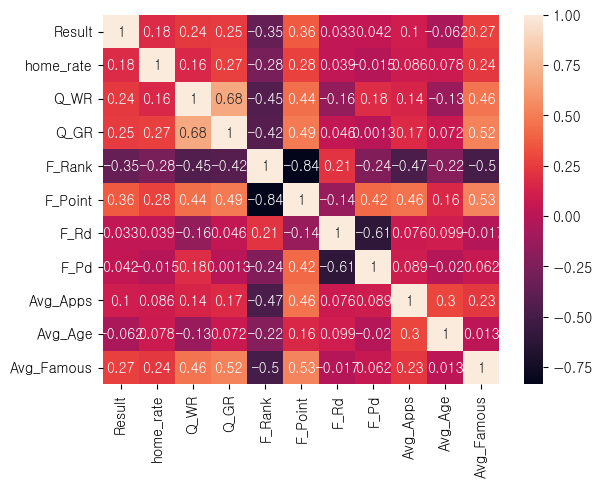

In [5874]:
corr_matrix = df_merged[['Result', 'home_rate', 'Q_WR', 'Q_GR', 'F_Rank', 'F_Point', 'F_Rd', 'F_Pd', 'Avg_Apps',
       'Avg_Age', 'Avg_Famous',]].corr()
sns.heatmap(corr_matrix, annot=True)
plt.show()

In [5875]:
from joblib import dump

dump(model, 'model.joblib') # 모델 저장

['model.joblib']